In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

root = Path.cwd().resolve()
if not (root / "database").exists():
    root = root.parent

science_file = (
    root
    / "database/observations/2026-08-09/CoRoT-2/session_01"
    / "CoRoT-2260809072715.fits"
)

dark_folder = root / "database/calibration/2026-08-09"
dark_files = sorted(dark_folder.glob("*.fits"))

raw = fits.getdata(science_file).astype("float32")

dark_images = [
    fits.getdata(path).astype("float32")
    for path in dark_files
]

master_dark = np.median(dark_images, axis=0)
calibrated = raw - master_dark

print("Science image:", raw.shape)
print("Dark images:", len(dark_images))

Science image: (500, 650)
Dark images: 2


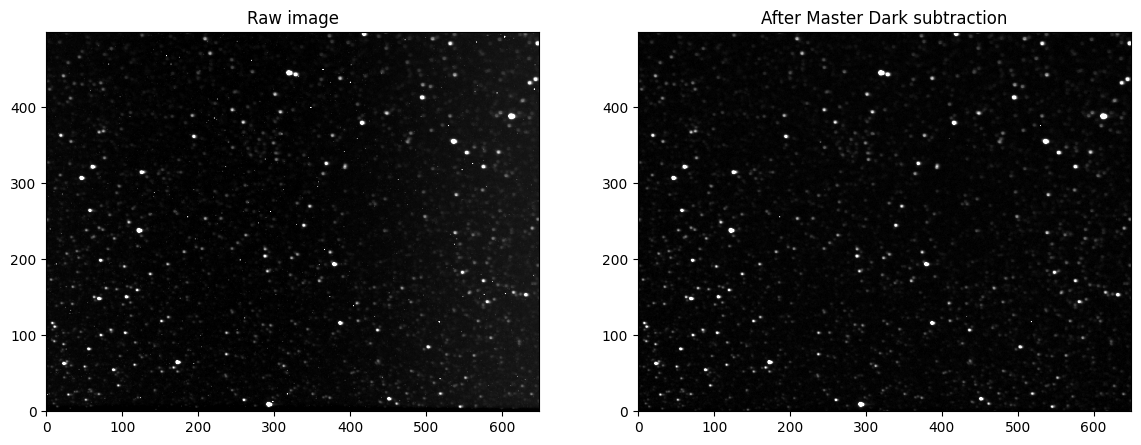

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, image, title in [
    (axes[0], raw, "Raw image"),
    (axes[1], calibrated, "After Master Dark subtraction"),
]:
    low, high = np.percentile(image, [5, 99.8])

    ax.imshow(
        image,
        origin="lower",
        cmap="gray",
        vmin=low,
        vmax=high
    )

    ax.set_title(title)

plt.show()

In [4]:
display_image = calibrated - np.median(calibrated)
low, high = np.percentile(display_image, [5, 99.8])

output_file = root / "tmp/corot2_for_astrometry.png"

plt.imsave(
    output_file,
    display_image,
    cmap="gray",
    origin="lower",
    vmin=low,
    vmax=high
)

print(output_file)

C:\Users\iix_m\Downloads\hack4dev\tmp\corot2_for_astrometry.png


In [6]:
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

wcs_file = (
    root
    / "outputs/corot_2/2026-08-09"
    / "wcs_plate_solve_CoRoT-2260809072715.fits"
)

wcs = WCS(fits.getheader(wcs_file))

corot2_sky = SkyCoord(
    ra=291.7770457,
    dec=1.3836634,
    unit="deg"
)

x, solved_y = wcs.world_to_pixel(corot2_sky)

# نعكس Y لأن صورة Astrometry حُفظت باتجاه عرض مختلف
y = (calibrated.shape[0] - 1) - solved_y

print("X =", x)
print("Y =", y)

X = 160.72412828692705
Y = 123.11386272125219


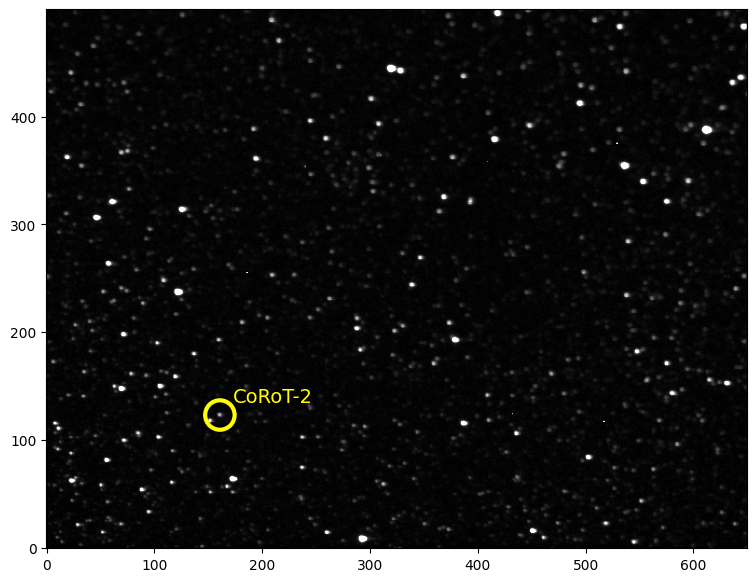

In [10]:
low, high = np.percentile(calibrated, [5, 99.8])

plt.figure(figsize=(10, 7))

plt.imshow(
    calibrated,
    origin="lower",
    cmap="gray",
    vmin=low,
    vmax=high
)

plt.scatter(
    x,
    y,
    s=450,
    facecolors="none",
    edgecolors="yellow",
    linewidths=3
)

plt.text(
    x + 12,
    y + 12,
    "CoRoT-2",
    color="yellow",
    fontsize=14
)

plt.show()

In [12]:
def measure_star(image, x, y, star_radius=5,
                 sky_inner=8, sky_outer=12):

    yy, xx = np.indices(image.shape)

    distance = np.sqrt(
        (xx - x) ** 2 +
        (yy - y) ** 2
    )

    star_pixels = distance <= star_radius

    sky_pixels = (
        (distance >= sky_inner) &
        (distance <= sky_outer)
    )

    sky_per_pixel = np.median(image[sky_pixels])

    star_sum = np.sum(image[star_pixels])
    background = sky_per_pixel * np.sum(star_pixels)

    true_flux = star_sum - background

    return true_flux, sky_per_pixel

In [13]:
target_flux, sky = measure_star(calibrated, x, y)

print("Measured target flux:", target_flux)
print("Background per pixel:", sky)

Measured target flux: 1771.5
Background per pixel: 29.5


In [14]:
comparison_positions = [
    (379.05, 192.73),
    (533.01, 355.71),
    (386.97, 115.36),
]

comparison_fluxes = []

for cx, cy in comparison_positions:
    flux, _ = measure_star(calibrated, cx, cy)
    comparison_fluxes.append(flux)

comparison_ensemble = np.median(comparison_fluxes)

relative_flux = target_flux / comparison_ensemble

print("Target flux:", target_flux)
print("Comparison ensemble:", comparison_ensemble)
print("Relative flux:", relative_flux)

Target flux: 1771.5
Comparison ensemble: 12851.0
Relative flux: 0.13784919461520503


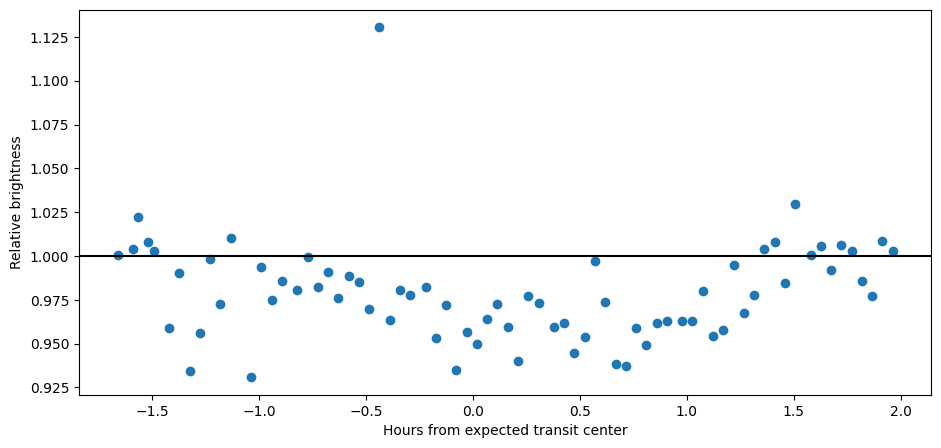

In [15]:
import pandas as pd

photometry = pd.read_csv(
    root / "outputs/corot_2/2026-08-09/photometry.csv"
)

accepted = photometry["accepted"]

plt.figure(figsize=(11, 5))

plt.scatter(
    photometry.loc[accepted, "hours_from_expected_mid"],
    photometry.loc[accepted, "detrended_flux"]
)

plt.axhline(1, color="black")

plt.xlabel("Hours from expected transit center")
plt.ylabel("Relative brightness")
plt.show()